## The CIFAR10 dataset

The dataset consistes of 60000 32x32 color images in 10 classes: plane, car, bird, cat, deer, dog, frog, horse, ship, truck, with 6000 images per class. This dataset can be downloaded directly from `PyTorch` using the `torchvision` module.  
So the original images are 32x32x3 arrays. The third dimension corresponds to color (red, green, blue). Ofcourse, it has to be turned into `PyTorch` tensors. Also, it is more convenient to scale them [-1, 1]. It can be achieved using a transformation


In [26]:
import torch
import torchvision
import torchvision.transforms as transforms

# Transform to be applied to each imager
transform = transforms.Compose([transforms.ToTensor(), # This turns the picture to a Tensor
 transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) # This scales it to [-1, 1]

# Here is how to load train dataset
trainset = torchvision.datasets.CIFAR10(root = '../data', train=True,
                                        download=False, transform=transform)
# And for loading test dataset
testset = torchvision.datasets.CIFAR10(root='../data', train=False,
                                       download=False, transform=transform)

 # These are the class labels
classes = ('plane', 'car', 'bird', 'cat',
 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

So all the data is stored into `../data/`. Here is what this folder contains:

In [27]:
!dir ..\data\

 Volume in drive C is Windows
 Volume Serial Number is A06C-7B5A

 Directory of c:\Users\GautamVishwa\Documents\Eye_Tracking\ScientificML\data-analytics-se\activities\data

20.07.2026  10:02    <DIR>          .
20.07.2026  09:25    <DIR>          ..
04.06.2009  22:47    <DIR>          cifar-10-batches-py
20.07.2026  10:02       170.498.071 cifar-10-python.tar.gz
               1 File(s)    170.498.071 bytes
               3 Dir(s)  1.432.500.375.552 bytes free


The file `cifar-10-python.tar.gz` is a compressed file containing everything. The contents were automatically extracted and put in the folder `cifar-10-batches-py`. Let's look inside this folder:

In [28]:
!dir ..\data\cifar-10-batches-py\

 Volume in drive C is Windows
 Volume Serial Number is A06C-7B5A

 Directory of c:\Users\GautamVishwa\Documents\Eye_Tracking\ScientificML\data-analytics-se\activities\data\cifar-10-batches-py

04.06.2009  22:47    <DIR>          .
20.07.2026  10:02    <DIR>          ..
31.03.2009  06:45               158 batches.meta
31.03.2009  06:32        31.035.704 data_batch_1
31.03.2009  06:32        31.035.320 data_batch_2
31.03.2009  06:32        31.035.999 data_batch_3
31.03.2009  06:32        31.035.696 data_batch_4
31.03.2009  06:32        31.035.623 data_batch_5
04.06.2009  22:47                88 readme.html
31.03.2009  06:32        31.035.526 test_batch
               8 File(s)    186.214.114 bytes
               2 Dir(s)  1.432.500.375.552 bytes free


So, there are several files. The important ones are `data_batch_1` to `data_data_5` and `test_batch`. Each of these contains 10,00 images in a binary format. The format is explained here. We can read them as follows:

In [29]:
def unpickle(file):
    import  pickle
    with open(file, 'rb') as fo:
        dict= pickle.load(fo, encoding='bytes')
    return dict

data = unpickle('../data/cifar-10-batches-py/data_batch_1')
# data is a dictionary
# Here are the keys
print(data.keys())

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])


In [12]:
#print(data[b'labels'])


In [13]:
# One key has to do with the pictures
# It gives you a numpy array
print(data[b'data'].shape)

(10000, 3072)


In [14]:
# The first dimension correspond to different pictures
# The second dimension is
32 * 32 *3

3072

In [30]:
# The first picture
img = data[b'data'][0, :].reshape((32, 32, 3), order='F')
# Here is the Red channel:
print(img[:,:,0])

[[ 59  16  25 ... 208 180 177]
 [ 43   0  16 ... 201 173 168]
 [ 50  18  49 ... 198 186 179]
 ...
 [158 123 118 ... 160 184 216]
 [152 119 120 ...  56  97 151]
 [148 122 109 ...  53  83 123]]


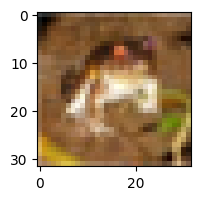

In [31]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(2,2))
ax.imshow(np.transpose(img, (1,0,2)))

In [17]:
img.shape

(32, 32, 3)

This looks like a frog! Let's verify this:

In [18]:
classes[data[b'labels'][0]]

'frog'

We can actually proceed further like above. However, `PyTorch` provides some helpful functionality. Let's investigate the `trainset` that was returned by `CIFAR10`.

In [32]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

Here are the classes.

In [6]:
trainset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

It also provides correspondense between classes and discrete labels.

In [7]:
trainset.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [8]:
# Here are the images from all training batches
trainset.data.shape

(50000, 32, 32, 3)

In [9]:
# The corresponding training labels
trainset.targets[:10]

[6, 9, 9, 4, 1, 1, 2, 7, 8, 3]

Alright.
Let's use `PyTorch` functionality for looping over the training and test datasets. We need a `DataLoader`.

In [33]:
# one for training data
trainloader = torch.utils.data.DataLoader(trainset, batch_size = 4,
                                        shuffle=True, num_workers=0)

# one for test data
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                       shuffle=True, num_workers=0)



These objects work as follows:

In [34]:
# They help you loop over all the image in a random way (because we had shuffle = True)
for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    # Here each images are of shape batch_size x (3 x 32 x 32)
    # Since, we choose batch_size to be 4.
    # This essentially loads 4 images per iteration
    if i%1000 == 0:
        print(f'Data point:', i, 'input size:', str(inputs.shape))

Data point: 0 input size: torch.Size([4, 3, 32, 32])
Data point: 1000 input size: torch.Size([4, 3, 32, 32])
Data point: 2000 input size: torch.Size([4, 3, 32, 32])
Data point: 3000 input size: torch.Size([4, 3, 32, 32])
Data point: 4000 input size: torch.Size([4, 3, 32, 32])
Data point: 5000 input size: torch.Size([4, 3, 32, 32])
Data point: 6000 input size: torch.Size([4, 3, 32, 32])
Data point: 7000 input size: torch.Size([4, 3, 32, 32])
Data point: 8000 input size: torch.Size([4, 3, 32, 32])
Data point: 9000 input size: torch.Size([4, 3, 32, 32])
Data point: 10000 input size: torch.Size([4, 3, 32, 32])
Data point: 11000 input size: torch.Size([4, 3, 32, 32])
Data point: 12000 input size: torch.Size([4, 3, 32, 32])


In this way using enumerate and 'DataLoader', we have visited all data at once. The `PyTorch` has reshaped the images to 3x32x32 3D arrays. This is more convenient for CNNs, that we will use later. Also, `PyTorch` uses the transformations we gave it to scale the data [-1, 1]. Let's see an example:

In [55]:
for i, data in enumerate(trainloader, 0):
    images, labels = data
    print(images.reshape(4, 3*32*32))
    break

tensor([[-0.4353, -0.4588, -0.4275,  ...,  0.7647,  0.7255,  0.7333],
        [ 0.2392,  0.2784,  0.3333,  ..., -0.4980, -0.5137, -0.5216],
        [-0.0667, -0.1137, -0.1137,  ..., -0.1686, -0.2078, -0.2784],
        [-0.4902, -0.4824, -0.3882,  ...,  0.9059,  0.9059,  0.9216]])


## Training a classifier using dense NNs

Let's start with a Dense NN, It could be better if we could use softmax in the last layer to map real outputs to probability. But for stability reasons, we will not end with softmax layer during traiining.

In [35]:
import torch.nn as nn

In [36]:
# We start from 3 x 32 x 32 which is the input shape flattened I guess and gradually take it to 10.
# And softmax layer is not used at the end.
model_dense = nn.Sequential(nn.Linear(3*32*32, 1176), nn.ReLU(),
                  nn.Linear(1176, 400), nn.ReLU(),
                  nn.Linear(400, 120), nn.ReLU(),
                  nn.Linear(120, 84), nn.ReLU(),
                  nn.Linear(84, 10))

# Add loss function
criterion = nn.CrossEntropyLoss()
# CrossEntropy loss use softmax internally to outut probability for each class
# It expects raw, unnormalized score for each class.



In [37]:
import torch.optim as optim

In [38]:
# Initialize the optimizer
optimizer = optim.SGD(model_dense.parameters(), lr=0.01)

In [39]:
# How many times you want to go over entire dataset
num_epochs = 2


for epoch in range(num_epochs):
    running_loss = 0.0
    # The training loop
    for i, data in enumerate(trainloader, 0):

        # get the inputs: data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + loss + backward + optimizer
        model_out = model_dense(inputs.reshape(4, 3 * 32 * 32))

        loss = criterion(model_out, labels)

        loss.backward()

        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 1000 == 999: #print every 1000 minibatches
            print('[%d %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 1000))
            running_loss = 0.0

print('Finished training')






[1  1000] loss: 2.288
[1  2000] loss: 2.107
[1  3000] loss: 1.948
[1  4000] loss: 1.854
[1  5000] loss: 1.773
[1  6000] loss: 1.733
[1  7000] loss: 1.673
[1  8000] loss: 1.663
[1  9000] loss: 1.614
[1 10000] loss: 1.604
[1 11000] loss: 1.597
[1 12000] loss: 1.555
[2  1000] loss: 1.521
[2  2000] loss: 1.461
[2  3000] loss: 1.521
[2  4000] loss: 1.500
[2  5000] loss: 1.487
[2  6000] loss: 1.472
[2  7000] loss: 1.455
[2  8000] loss: 1.469
[2  9000] loss: 1.431
[2 10000] loss: 1.446
[2 11000] loss: 1.406
[2 12000] loss: 1.426
Finished training


Since, training networks takes a while. It is good idea to save it

In [ ]:
#torch.save(model_dense.state_dict(), 'hands-on-lec-25.pth')

Let's make some predictions

In [61]:
# Load a batch of images and labels from unseen test dataset!
dataiter = iter(testloader)
images, labels = next(dataiter)

# Pass it through the trainied dense network. In order to set 
# the score the output of the trained dense network has to pass 
# through the softmax function
st = nn.Softmax(1)
predictions = st(model_dense(images.reshape(4, 3 * 32 * 32)))



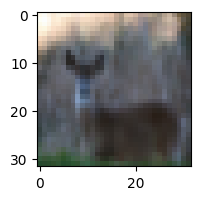

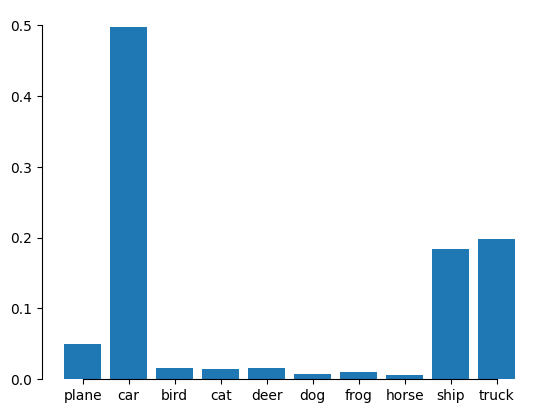

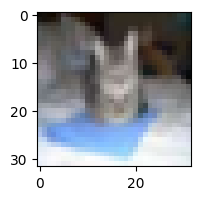

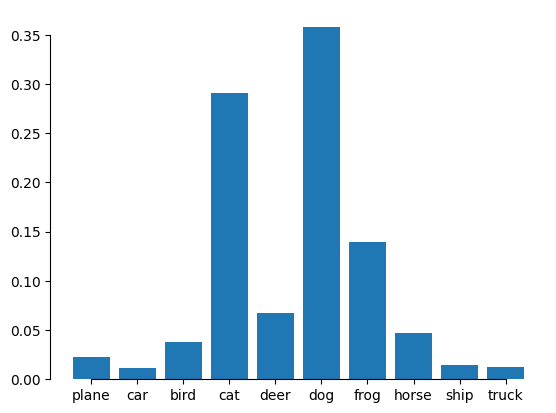

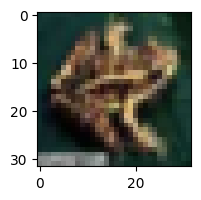

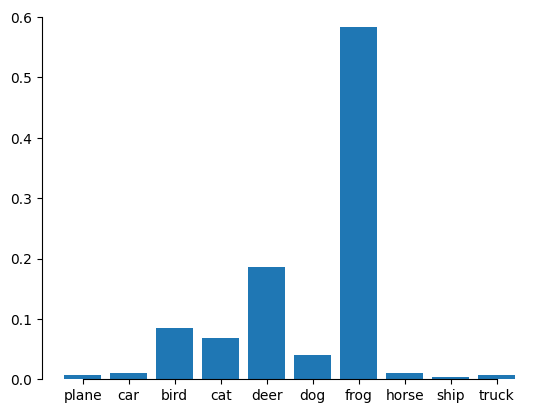

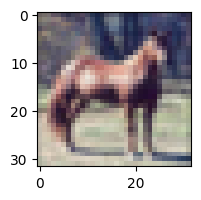

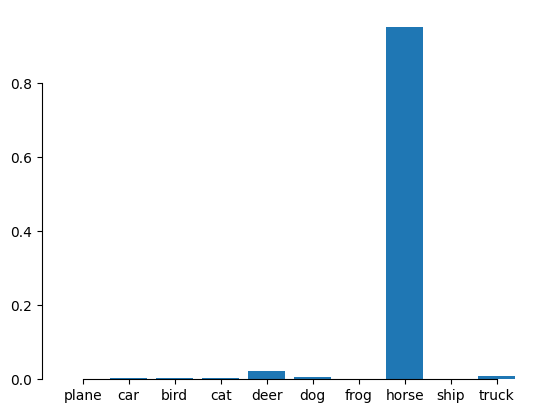

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
def imshow(img, ax):
    img = img/2 + 0.5
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))

# Plot the pictures and predictions
for i in range(4):
    fig, ax = plt.subplots(figsize=(2,2))
    imshow(images[i], ax)
    fig2, ax2 = plt.subplots()
    ax2.bar(np.arange(10), predictions[i].detach().numpy())
    ax2.set_xticks(np.arange(10))
    ax2.set_xticklabels(classes)
    sns.despine(trim=True)

Let's plot the accuracy for each of the class

In [64]:
# Initialize two list for holding the correct and total number of different classes
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
    for i, data in enumerate(testloader, 0):
        images, labels = data # unpacking
        # get predictions
        dmodel_scores = st(model_dense(images.reshape(4, 3*32*32)))
        _, dmodel_predictions = torch.max(dmodel_scores, 1)
        c = (dmodel_predictions == labels).squeeze()
        for j in range(4):
            label = labels[j]
            class_correct[label] += c[j].item()
            class_total[label] += 1

for i in range(10):
    print('Accuracy of %5s : %2d %%' % (classes[i], 100 * class_correct[i] / class_total[i]))

        


Accuracy of plane : 37 %
Accuracy of   car : 70 %
Accuracy of  bird : 45 %
Accuracy of   cat : 27 %
Accuracy of  deer : 46 %
Accuracy of   dog : 39 %
Accuracy of  frog : 52 %
Accuracy of horse : 48 %
Accuracy of  ship : 69 %
Accuracy of truck : 43 %


Let's get the overall accuray to compare later with CNN 

In [65]:
print('The overall accuracy is %3d %%' % (100 * sum(class_correct) / sum(class_total)))

The overall accuracy is  48 %


Now, let's do the same thing with Convolutional Neural Network. Instead of using `nn.Sequential`, let's use `nn.Module` to manually create a network. You need to inherit `nn.Module`, and implement `__init__()` and `forward()`.

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # A convolutional layer:
        # 3 = input channels (colors)
        # 6 = output channels (features)
        # 5 = kernel size
        self.conv1 = nn.Conv2d(3, 6, 5) #out: batch_size x (6 x 14 x 14)

        # A 2 x 2 maxpooling layer -> we are going to use it two times
        self.pool = nn.MaxPool2d(2, 2)

        # Another convolution layer
        self.conv2 = nn.Conv2d(6, 16, 5)

        # Linear layers
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # This function implements your network output
        # Convolution layer followed by ReLU and then max pooling
        x = self.pool(F.relu(self.conv1(x))) # out: batch_size x (6 x 14 x 14)
        x = self.pool(F.relu(self.conv2(x))) # out: batch_size x (16 x 5 x 5)
        x = x.flatten(1, -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return x

    
model_cnn = Net()

Here is the optimizer:

In [15]:
import torch.optim as optim
optimizer = optim.SGD(model_cnn.parameters(), lr = 0.01)

Here is the training loop. Notice that this network traings faster! It is a CNN instead of earlier Dense NN.

In [ ]:
# number of iterations the training loop has to go through all the training data
num_epochs = 100

# batch size just defined here in case you just want to run the CNN model
batch_size = 1000

# store training loss for later use
training_loss = []
test_loss = []

# define loss function
loss_ft = nn.CrossEntropyLoss()

for epoch in range(num_epochs):

    # accumulate running loss
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):

        # Zero out the gradient buffers
        optimizer.zero_grad()

        image, labels = data

        # forward
        cnn_predict = model_cnn(image.reshape(1000, 3, 32, 32))
        #loss calculation
        loss = loss_ft(cnn_predict, labels)

        #if epoch == 1:
        #    training_loss.append(loss.item())
        # Pytorch magic of backward gradient calculation
        loss.backward()
        # Weight update
        optimizer.step()

        # accumulate running loss
        running_loss += loss.item()

        # print statistics
        if i % 1000 == 999: # every 1000 iterations
            print('[%d %5d] Loss: %.3f'% (epoch+1, i+1, running_loss / 1000) )
            running_loss = 0.0 # to get loss at every 1000 iterations

        

print('Training Finished')




[1  1000] Loss: 1.050
[1  2000] Loss: 1.045
[1  3000] Loss: 1.042
[1  4000] Loss: 1.056
[1  5000] Loss: 1.094
[1  6000] Loss: 1.075
[1  7000] Loss: 1.053
[1  8000] Loss: 1.063
[1  9000] Loss: 1.058
[1 10000] Loss: 1.077
[1 11000] Loss: 1.041
[1 12000] Loss: 1.065
[2  1000] Loss: 1.072
[2  2000] Loss: 1.063
[2  3000] Loss: 1.061
[2  4000] Loss: 1.071
[2  5000] Loss: 1.050
[2  6000] Loss: 1.061
[2  7000] Loss: 1.066
[2  8000] Loss: 1.073
[2  9000] Loss: 1.044
[2 10000] Loss: 1.049
[2 11000] Loss: 1.082
[2 12000] Loss: 1.045
[3  1000] Loss: 1.076
[3  2000] Loss: 1.038
[3  3000] Loss: 1.065
[3  4000] Loss: 1.044
[3  5000] Loss: 1.077
[3  6000] Loss: 1.043
[3  7000] Loss: 1.051
[3  8000] Loss: 1.076
[3  9000] Loss: 1.077
[3 10000] Loss: 1.059
[3 11000] Loss: 1.065
[3 12000] Loss: 1.061
[4  1000] Loss: 1.074
[4  2000] Loss: 1.074
[4  3000] Loss: 1.089
[4  4000] Loss: 1.053
[4  5000] Loss: 1.049
[4  6000] Loss: 1.071
[4  7000] Loss: 1.049
[4  8000] Loss: 1.050
[4  9000] Loss: 1.061
[4 10000] 

Plot the training loss curve Vs iterations

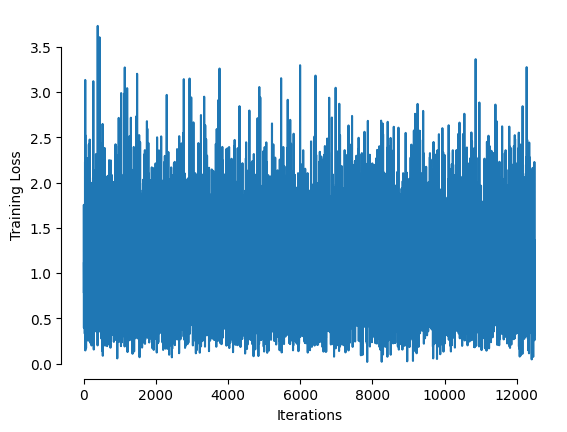

In [69]:
import seaborn as sns
fig, ax = plt.subplots(dpi = 100)
ax.plot(training_loss)
ax.set_xlabel('Iterations')
ax.set_ylabel('Training Loss')
sns.despine(trim=True)

Make some predictions

In [20]:
# get first 4 images and their labels
dataiter = iter(testloader)
images, labels = next(dataiter)


In [21]:
st = nn.Softmax(dim=1)

test_predictions = st(model_cnn(images))

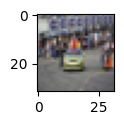

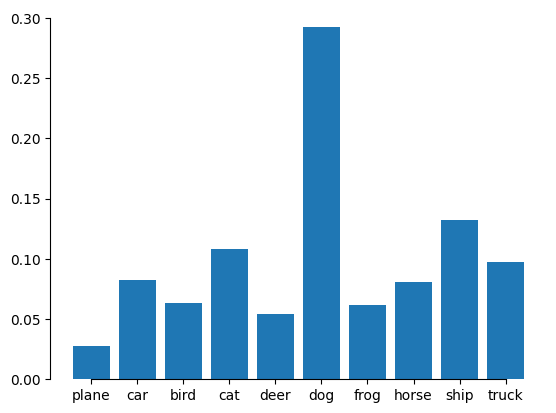

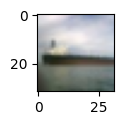

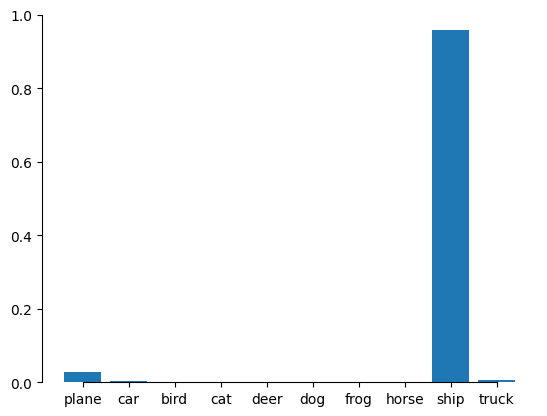

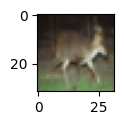

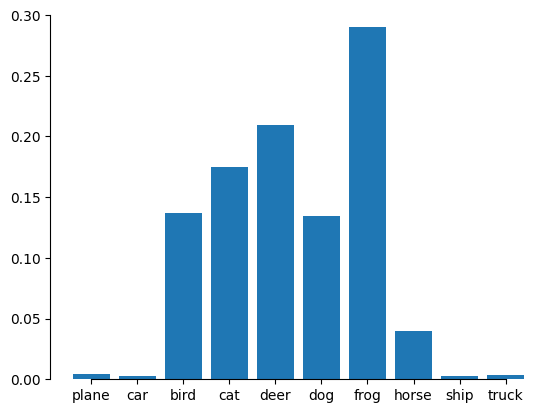

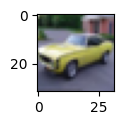

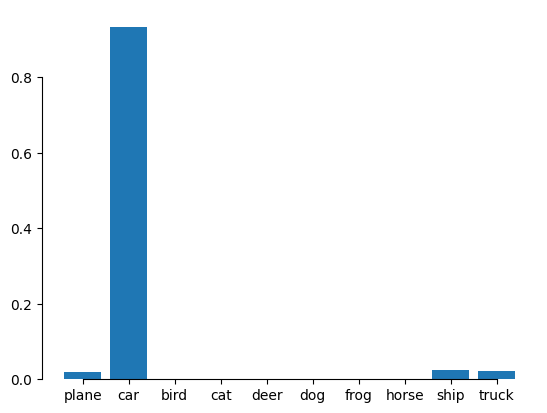

In [23]:
def imshow(img, ax):
    img = img/2 + 0.5 # unnormalize
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1,2,0)))

# plot the pictures and the predictions
for i in range(4):
    fig, ax = plt.subplots(figsize=(2,1))
    imshow(images[i], ax)
    fig2, ax2 = plt.subplots()
    ax2.bar(np.arange(10), test_predictions[i].detach().numpy())
    ax2.set_xticks(np.arange(10))
    ax2.set_xticklabels(classes)
    sns.despine(trim=True)

It doesn't work equally well for all classes. Here is some code from the `pytorch` tutorial to get the accuracy for each class:

In [66]:
class_correct = list(0. for i in range(10))
class_total= list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model_cnn(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))


Accuracy of plane : 63 %
Accuracy of   car : 79 %
Accuracy of  bird : 39 %
Accuracy of   cat : 56 %
Accuracy of  deer : 42 %
Accuracy of   dog : 57 %
Accuracy of  frog : 60 %
Accuracy of horse : 60 %
Accuracy of  ship : 78 %
Accuracy of truck : 52 %


In [67]:
print('The overall accuracy of CNN is %2d %%' % (100 * sum(class_correct) / sum(class_total)))

The overall accuracy of CNN is 58 %


So, CNN outperforms the Dense NN by a margin of 16 %.